In [19]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Function to define the actions
def get_actions(state, param):
  return 1 if state @ param > 0 else 0

In [26]:
# Function to calculate total reward
def play_one_episode(env, params):
  observation, info = env.reset()
  total_reward = 0
  done = False

  while not done:
    action = get_actions(observation, params)
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward

  return total_reward

In [36]:
# Function to run multiple iterations of episodes
def play_multiple_episodes(env, num_episodes, params):
  episode_rewards = np.mean([play_one_episode(env, params) for _ in range(num_episodes)])
  return episode_rewards


In [37]:
# Function for random search

def random_search(env, num_episodes, num_updates):

  # Set hyperparameters
  best_reward = 0
  best_params = None
  total_rewards = []

  for _ in range(num_updates):
    new_params = np.random.random(4) * 2 - 1 # To ensure parameters are between -1 and 1
    rewards = play_multiple_episodes(env, num_episodes, new_params)
    total_rewards.append(rewards)

    if rewards > best_reward:
      best_reward = rewards
      best_params = new_params

  return best_params, total_rewards



In [38]:
env = gym.make('CartPole-v1')
num_episodes_per_update = 100
num_updates = 100

best_params, total_rewards = random_search(env, num_episodes_per_update, num_updates)

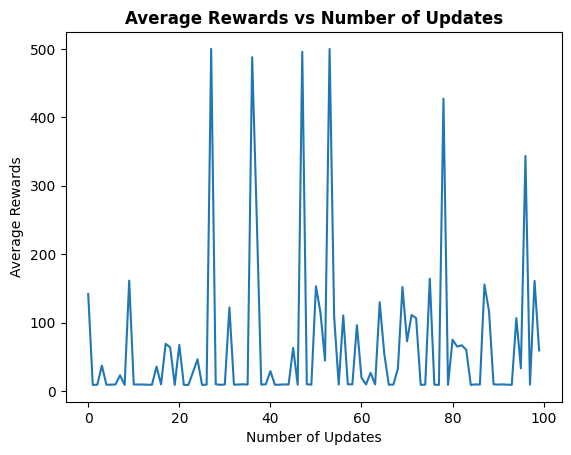

In [40]:
# Visualize the rewards
plt.plot(total_rewards)
plt.xlabel('Number of Updates')
plt.ylabel('Average Rewards')
plt.title('Average Rewards vs Number of Updates', fontweight='bold')
plt.show()